 # **Case Study - Feature Selection Optimisation to Predict Vehicle Price**

## 📝 **Executive Summary**

This project aimed to develop a predictive model for vehicle prices and evaluate how different feature selection strategies impact model performance and generalisation.

Multiple feature selection approaches were applied, including mutual information filtering, correlation based reduction, domain knowledge, and recursive feature elimination (RFE). Each resulting feature set was used to train and evaluate a decision tree regression model.

The results show that while models using more refined feature selection techniques often achieved higher accuracy on the test set, they also demonstrated signs of overfitting when evaluated using cross validation. In particular, the model based on domain knowledge achieved the highest R² score, but with a noticeable drop in cross validation performance.

In contrast, the model using correlation based feature reduction showed lower test accuracy but slightly stronger cross validation performance. The model developed using analytical feature selection provided a more balanced outcome, with better test accuracy than the correlation-based model and stronger generalisation than the domain expert model, as reflected in its cross validated R² score.

These results highlight the importance of considering both accuracy and generalisation when selecting features. They also demonstrate that overly aggressive feature reduction or reliance on a single method can remove useful predictive information, while a balanced approach can lead to more robust models. Feature importance analysis further demonstrated that different feature selection strategies can significantly influence which variables are considered most predictive, reinforcing the need for careful feature selection.

From a business perspective, the optimal model depends on the intended use case. In stable markets where future data closely resembles the training data (e.g. vehicles from a similar set of manufacturers), a higher accuracy model may be preferred. However, in more dynamic environments where new or unseen data is expected (e.g. the introduction of new manufacturers), a model with stronger generalisation performance is likely to provide more reliable and robust predictions.

## 🚗 **Business Context**
Accurate vehicle pricing is critical for automotive businesses seeking to balance profitability and sales velocity. Overpricing can increase the time required to sell, while underpricing may reduce margins.

However, improving model performance may lead to higher operational costs, such as increased data storage and computational requirements, driven by greater model and feature set complexity.

Conversely, collecting, storing, and processing large volumes of data incurs operational costs. Therefore, identifying the optimal set of predictive features is important not only for model accuracy, but also for efficiency and scalability in a production environment.

## 🎯 **Project Objective**
The objective of this project is to evaluate how different feature engineering and feature selection techniques impact regression model performance when predicting vehicle selling prices.

The primary goal is to determine the optimal set of features that maintains strong predictive performance while balancing trade-offs between model simplicity, cost-efficiency, and generalisability to previously unseen data, such as new vehicle manufacturers and models.


### 📊 Dataset Overview

The dataset was loaded from an external source and initially explored to understand its structure, data types, and overall quality. This included reviewing sample records, inspecting feature types, analysing summary statistics, and checking for missing values.

These steps provide an initial understanding of the dataset and help identify potential data quality issues prior to cleaning and modelling.

In [1]:
# Import the required libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Import the automobiles.csv file (data set) from GitHub with a url.
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/automobiles.csv"

In [2]:
x = pd.read_csv(url)

In [3]:
x.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [4]:
# Data information and descriptive statistics
print(x.info())
x.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
# Set Car ID as index
x.set_index('car_ID', inplace=True)
x.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
# Check for null values
x.isnull().sum()

,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0


In [7]:
# Check unique values for CarName
x['CarName'].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

Initial observations from reviewing the car names include:


*   Multiple vehicles are present for several car brands, suggesting that extracting the manufacturer as a separate feature may provide useful predictive information
*   There are inconsistencies in brand naming (e.g. "volkswagen" and "vw"), which should be standardised to ensure data consistency
*   Some data entry errors are present (e.g "toyouta"), which require correction as part of the data cleaning process
*   The car model could be a potentially useful feature, however, it would require significant feature engineering to extract meaningful information. Additionally, using this feature may increase the risk overfitting due to the limited coverage of individual models within the dataset

These observations informed the data cleaning and feature engineering steps applied in subsequent sections.

### 🧹 Data Cleaning & Preparation

Following the initial data exploration, several data cleaning steps were performed to address inconsistencies, correct errors, and prepare the dataset for modelling.

The car brand was extracted from the "Car Name" feature to create a new categorical variable. This simplifies the representation of manufacturer information and enables it to be used more effectively within the model.

Brand naming inconsistencies and data entry errors were also corrected to ensure consistency across the dataset.

In [8]:
# Extract Car Brand from CarName and view all car brands
x['CarBrand'] = x['CarName'].apply(lambda y: y.split(" ")[0])
x['CarBrand'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [9]:
# Correct typos
x.loc[(x.CarBrand == 'alfa-romero'), 'CarBrand'] = 'alfa-romeo'
x.loc[(x.CarBrand == 'maxda'), 'CarBrand'] = 'mazda'
x.loc[(x.CarBrand == 'porcshce'), 'CarBrand'] = 'porsche'
x.loc[(x.CarBrand == 'toyouta'), 'CarBrand'] = 'toyota'
x.loc[(x.CarBrand == 'vokswagen'), 'CarBrand'] = 'volkswagen'

# Change vw brand to volkswagen
x.loc[(x.CarBrand == 'vw'), 'CarBrand'] = 'volkswagen'

# Change capitalisation of Nissan (and other brands if they were applicable)
x['CarBrand'] = x['CarBrand'].apply(lambda y: y.lower())
x['CarBrand'].unique()

array(['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

Car brands with a low number of observations were grouped into an "Other" category. This helps to reduce sparsity in the dataset and improves the model’s ability to generalise by avoiding overfitting to rarely occurring categories.

In [10]:
# Group brands with fewer than 10 records
Other_brands = x['CarBrand'].value_counts()[x['CarBrand'].value_counts() < 10].index
Other_brands_dict = dict.fromkeys(Other_brands,'other')
x_1 = x
x_1['CarBrand'] = x_1['CarBrand'].replace(Other_brands_dict)
x_1['CarBrand'].value_counts()

,count
CarBrand,
other,66
toyota,32
nissan,18
mazda,17
honda,13
mitsubishi,13
volkswagen,12
subaru,12
peugeot,11


As part of the data cleaning process, an inconsistency between the "Car Name" and "fueltype" features was identified during the initial exploration. This issue was investigated in more detail to determine whether corrective action was required.

In [11]:
# Check CarName for names that include diesel and check fuel type
x[x['CarName'].apply(lambda y: 'diesel' in y)]

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand
car_ID,,,,,,,,,,,,,,,,,,,,,
10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,178.2,...,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167,other
115,0,peugeot 505s turbo diesel,diesel,turbo,four,wagon,rwd,front,114.2,198.9,...,idi,3.70,3.52,21.0,95,4150,25,25,17075.000,peugeot
200,-1,volvo diesel,gas,turbo,four,wagon,rwd,front,104.3,188.8,...,mpfi,3.62,3.15,7.5,162,5100,17,22,18950.000,volvo


From the initial data exploration of the first 10 rows, it had been observed that the Car Name "audi 5000s (diesel)" did not match the fuel type (gas). Upon further investigation, there are two other vehicles with diesel in the Car Name. Of the three vehicles identified, two have been marked as gas which indicates an error with the data entry. However, looking at the other features such as fuel system, compression ratio and mpg, it is most likely that the error is contained in the car name, as those values are most closely aligned with a petrol engine. Therefore, the data for these rows will remain in the dataset unchanged.

In [12]:
# Drop CarName column as it is no longer needed
x.drop('CarName',axis = 1, inplace=True)

Categorical variables were encoded to enable their use in the regression model. Ordinal encoding was applied to features with a natural ordering (e.g. number of doors, number of cylinders), while one-hot encoding was used for nominal variables to avoid introducing artificial relationships between categories.

In [13]:
# Check unique values for door number and cylinder number
print(x['doornumber'].unique())
print(x['cylindernumber'].unique())

['two' 'four']
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']


In [14]:
# Use ordinal encoding by mapping number strings to integer values
x['doornumber'] = x['doornumber'].map({'two': 2, 'four': 4})
x['cylindernumber'] = x['cylindernumber'].map({'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12})
x[['doornumber','cylindernumber']].head()

,doornumber,cylindernumber
car_ID,,
1,2,4
2,2,4
3,2,6
4,4,4
5,4,5


In [15]:
# Initialise OneHotEncoder
encoder = OneHotEncoder(sparse_output= False)

# Create list of categorical columns
cat_columns = ['fueltype','aspiration','carbody', 'drivewheel', 'enginelocation','enginetype','fuelsystem','CarBrand']

# One-hot encode categorical columns
one_hot_encoded_columns = encoder.fit_transform(x[cat_columns])

# Create DataFrame with encoded columns
one_hot_df = pd.DataFrame(one_hot_encoded_columns, columns= encoder.get_feature_names_out(cat_columns), index = x.index)

# Concatenate DataFrames (x_1 and encoded columns)
x_1 = pd.concat([x_1, one_hot_df], axis = 1)

# Drop original categorical columns
x_1.drop(cat_columns, axis= 1, inplace= True)

# View data
x_1.head()


,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,CarBrand_honda,CarBrand_mazda,CarBrand_mitsubishi,CarBrand_nissan,CarBrand_other,CarBrand_peugeot,CarBrand_subaru,CarBrand_toyota,CarBrand_volkswagen,CarBrand_volvo
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 🛠 Data Preparation for Modelling

The dataset was prepared for modelling by separating the input features from the target variable and splitting the data into training and test sets. This allows model performance to be evaluated on unseen data.

Feature scaling was applied using Min-Max scaling to ensure that all numerical features are on a comparable scale, which can improve model performance and stability.

In [16]:
# Split the data into input features and target variable
X = x_1.drop('price', axis = 1)
y = x_1['price']

# Create training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 24)

X_train = X_train.copy()
X_test = X_test.copy()

In [17]:
# Normalise features (assume distribution is not normal)
min_max_scaler = MinMaxScaler()

# Apply MinMaxScaler to columns from 'symboling' to 'highwaympg' for training and test datasets
X_train.loc[:, 'symboling':'highwaympg'] = min_max_scaler.fit_transform(X_train.loc[:, 'symboling':'highwaympg'])
X_test.loc[:, 'symboling':'highwaympg'] = min_max_scaler.transform(X_test.loc[:, 'symboling':'highwaympg'])

/tmp/ipykernel_1543/4266240742.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4 0.8 0.8 0.6 0.4 0.6 0.4 0.4 0.4 1.  0.6 1.  0.2 0.4 0.4 0.4 0.2 0.2
 1.  0.2 0.6 0.4 0.4 0.6 0.4 0.6 1.  0.8 0.4 0.4 0.8 0.6 1.  0.4 0.6 0.4
 0.2 0.4 1.  1.  0.8 0.6 1.  1.  1.  0.4 0.4 0.4 0.6 1.  0.2 0.2 0.8 0.6
 0.4 0.4 0.2 1.  0.6 0.4 0.4 0.6 0.4 0.4 1.  0.4 0.6 0.8 0.4 0.8 0.4 0.6
 0.6 0.4 0.4 0.6 0.4 0.4 0.4 0.4 0.8 0.4 0.6 0.2 0.6 0.4 0.8 0.6 0.6 0.6
 0.6 0.8 0.6 0.6 0.2 0.4 0.4 0.8 0.6 0.8 0.6 1.  0.6 0.8 0.2 0.6 0.6 0.6
 0.6 0.6 0.6 0.4 0.4 0.4 0.8 0.4 0.8 0.6 0.8 0.6 1.  0.4 0.8 0.8 1.  0.8
 0.2 0.6 0.8 0.6 0.6 0.4 0.8 1.  0.6 0.2 1.  0.4 0.  0.6 0.4 1.  0.2 0.6
 0.4 0.8 0.6 0.8 0.4 0.4 0.4 0.  0.8 1.  0.8 0.2 0.4 0.6 0.2 0.4 0.6 0.4
 0.8 0.4]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, 'symboling':'highwaympg'] = min_max_scaler.fit_transform(X_train.loc[:, '

Numerical features for scaling were selected based on their position within the dataset following preprocessing, as the column structure was fixed at this stage.

In [18]:
x_1.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,CarBrand_honda,CarBrand_mazda,CarBrand_mitsubishi,CarBrand_nissan,CarBrand_other,CarBrand_peugeot,CarBrand_subaru,CarBrand_toyota,CarBrand_volkswagen,CarBrand_volvo
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


The dataset is now prepared for modelling, with features appropriately scaled and split into training and test sets.

### 🔍 Exploratory Analysis

Exploratory data analysis was conducted to identify relationships between features and assess potential multicollinearity prior to feature selection and modelling.

The correlation matrix was computed on numerical features only, excluding one-hot encoded variables to improve interpretability.

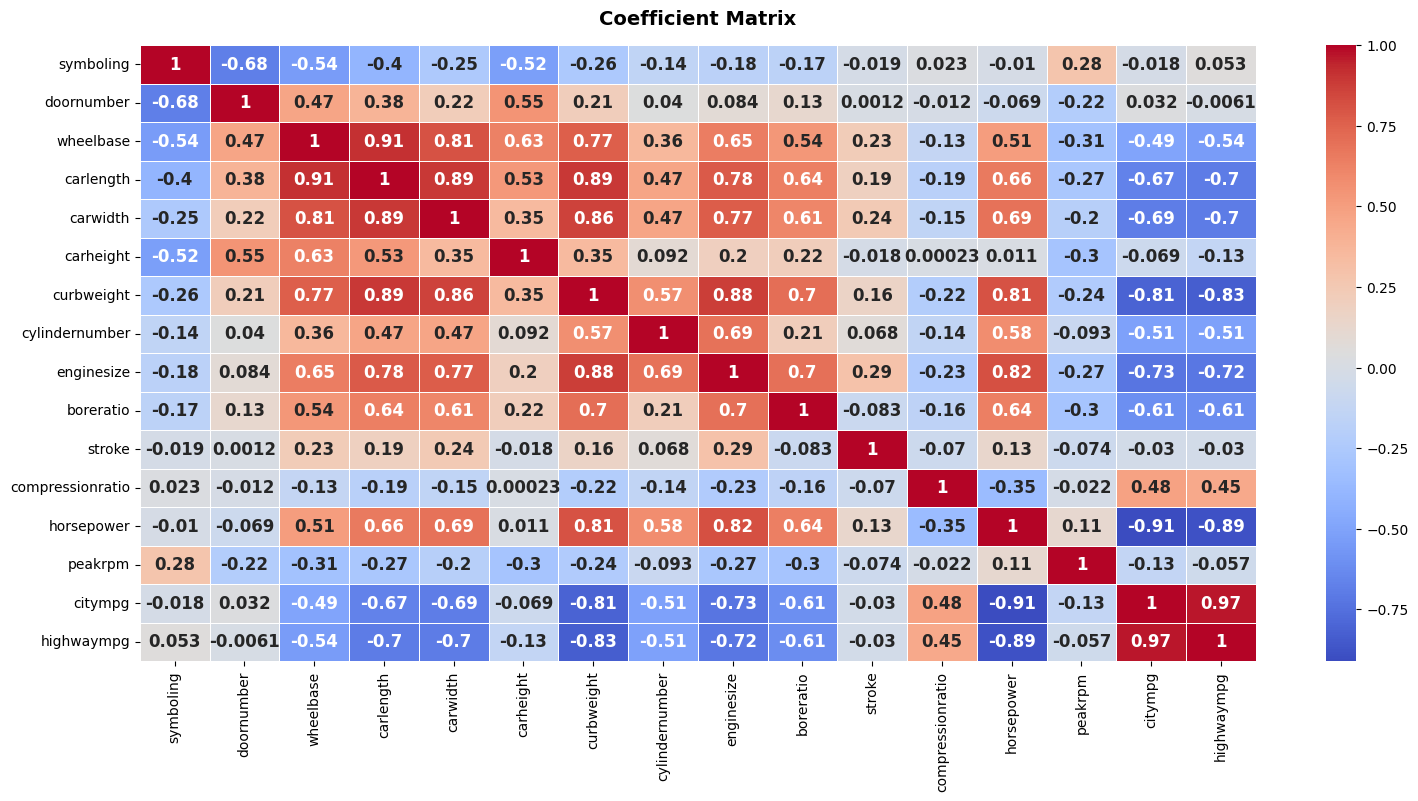

In [19]:
# Check for correlation between features (excluding OHE features)
x_1_corr = x_1.loc[:, 'symboling':'highwaympg'].corr(method = 'spearman') # spearman selected due to presence of ordinal data

plt.figure(figsize=(18, 8))
plt.title("Coefficient Matrix",{'fontweight':'bold','fontsize':14},y = 1.02)
sns.heatmap(x_1_corr, annot=True, cmap='coolwarm', linewidths = 0.5, annot_kws={'fontsize':12,'fontweight':'bold'})

plt.show()

Analysis of the correlation matrix shows several features with strong positive and negative relationships.

Highly correlated features such as wheelbase and car length, as well as city mpg and highway mpg, capture very similar information, so strong positive correlation was expected.

Strong negative correlations are primarily observed between vehicle and engine attributes (e.g. curb weight, horsepower) and fuel efficiency metrics (mpg). This aligns with domain knowledge, as larger and more powerful vehicles typically consume more fuel, resulting in lower mpg values.

These relationships indicate the presence of multicollinearity within the dataset. However, rather than removing features at this stage, further analysis using Mutual Information will be performed to better understand the predictive importance of each feature.

### 🧠 Feature Selection Strategies

Feature selection techniques were applied to evaluate how different approaches impact model performance and generalisation. Multiple strategies were explored, including mutual information filtering, correlation-based reduction, domain knowledge, and recursive feature elimination (RFE).

Each feature set was used to train a decision tree regression model, allowing for comparison of performance across different selection methods.

#### Baseline Model (All Features)

A baseline model was trained using all available features to establish a reference point for evaluating the impact of feature selection.

In [20]:
# Test the accuracy of a decision tree model using all of the features
model_1 = DecisionTreeRegressor(random_state = 24).fit(X_train, y_train)

# Get the predictions
pred_1 = model_1.predict(X_test)

# Calculate r2, MAE and RMSE
r2_1 = r2_score(y_test, pred_1)
mae_1 = mean_absolute_error(y_test, pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, pred_1))

# Perform cross validation for r2
cv_scores_1 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 1 (All Features)")
print(f"R²: {r2_1:.3f}")
print(f"MAE: £{int(mae_1):,d}")
print(f"RMSE: £{int(rmse_1):,d}")
print(f"Cross-validated R²: {cv_scores_1.mean():.3f}")

Model 1 (All Features)
R²: 0.852
MAE: £1,703
RMSE: £2,590
Cross-validated R²: 0.756


The model achieved an R² score of 0.85 on the test set, which decreased to approximately 0.76 when evaluated using cross-validation. This gap suggests a degree of overfitting, providing a useful benchmark for assessing the impact of subsequent feature selection techniques.

#### Mutual Information (Baseline Filtering)

Mutual Information was used to assess the dependency between each feature and the target variable, providing a measure of feature importance.

In [21]:
# Calculate the MI score for the input features
mi_scores = mutual_info_regression(X_train, y_train)

# Assign feature name to scores and sort in descending order of MI score
mi_scores_sorted = pd.Series(mi_scores, name = 'MI Scores', index = X_train.columns).sort_values(ascending = False)

# Print the MI scores
print(mi_scores_sorted)

horsepower              9.057351e-01
curbweight              8.747196e-01
enginesize              8.393567e-01
highwaympg              8.163151e-01
citympg                 6.397027e-01
carwidth                6.170260e-01
carlength               5.803596e-01
wheelbase               5.400246e-01
boreratio               4.609116e-01
cylindernumber          3.852907e-01
drivewheel_rwd          3.070230e-01
fuelsystem_mpfi         3.033994e-01
drivewheel_fwd          3.016109e-01
fuelsystem_2bbl         2.863445e-01
stroke                  2.758816e-01
carheight               2.733425e-01
CarBrand_other          2.134472e-01
peakrpm                 1.715235e-01
symboling               1.590785e-01
compressionratio        1.510939e-01
carbody_hatchback       1.088401e-01
aspiration_std          8.093573e-02
aspiration_turbo        8.093573e-02
CarBrand_volvo          6.788914e-02
enginetype_ohc          6.694159e-02
CarBrand_peugeot        5.172164e-02
enginetype_ohcv         4.936207e-02
e

Analysis of the Mutual Information (MI) scores indicates that vehicle and engine characteristics, particularly those related to size and performance, have the strongest influence on price.

Several features with similar underlying information (e.g. city mpg and highway mpg) also demonstrate comparable MI scores, suggesting potential redundancy within the dataset.

Features with very low MI scores are likely to contribute little predictive value and may be candidates for removal. A threshold of 0.1 was selected to filter out low-importance features while retaining those with meaningful predictive contribution. The impact of this filtering on model performance was then evaluated.

In [22]:
# Find index numbers of features with MI score greater than 0.1
top_mi_score_features_index = np.where(mi_scores > 0.1)[0]

# Filter out features with an MI score greater than 0.1
X_train_2 = X_train.iloc[:, top_mi_score_features_index]
X_test_2 = X_test.iloc[:, top_mi_score_features_index]

# Check the number of remaining features after filtering
print(f"{len(top_mi_score_features_index)} features retained after MI filtering")

21 features retained after MI filtering


In [23]:
# Test the accuracy of a decision tree model for the features with an MI score > 0.1
model_2 = DecisionTreeRegressor(random_state = 24).fit(X_train_2, y_train)

# Get the predictions
pred_2 = model_2.predict(X_test_2)

# Calculate r2, MAE and RMSE
r2_2 = r2_score(y_test, pred_2)
mae_2 = mean_absolute_error(y_test, pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred_2))

# Perform cross validation for r2
cv_scores_2 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train_2,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 2 (MI Threshold)")
print(f"R²: {r2_2:.3f}")
print(f"MAE: £{int(mae_2):,d}")
print(f"RMSE: £{int(rmse_2):,d}")
print(f"Cross-validated R²: {cv_scores_2.mean():.3f}")

Model 2 (MI Threshold)
R²: 0.868
MAE: £1,673
RMSE: £2,438
Cross-validated R²: 0.736


After removing features with an MI score ≤ 0.1, the model achieved an improved R² score of 0.87. However, the cross validated R² decreased to approximately 0.74.

This suggests that while the model performance improved on the test set, the reduction in cross validation performance indicates a potential increase in overfitting.

#### Handling Multicollinearity

Further analysis was conducted to assess multicollinearity by examining feature correlations. This informed subsequent feature selection strategies, where different approaches were applied to handle correlated variables.

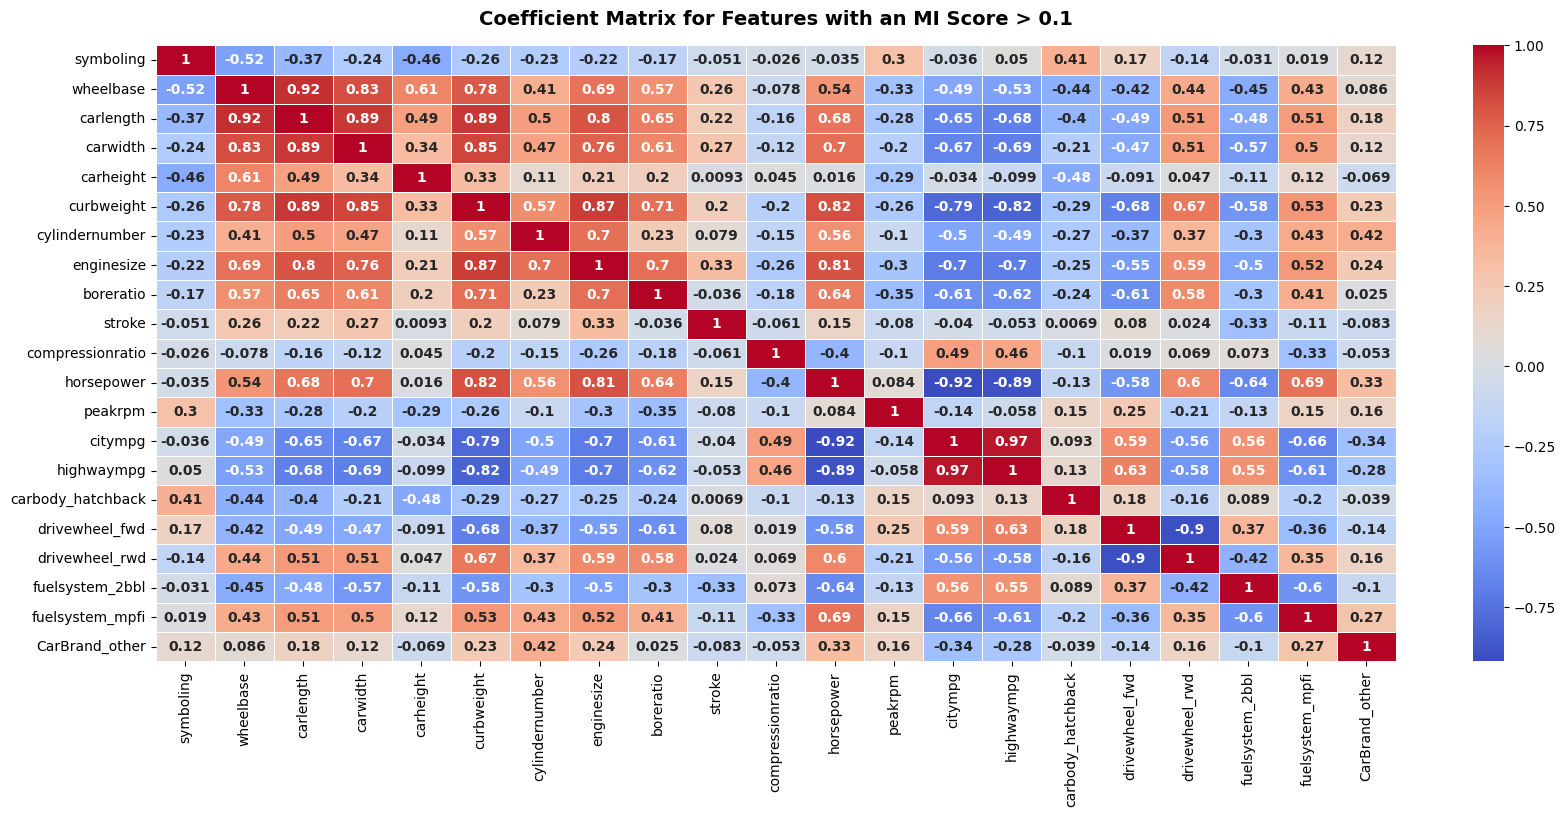

In [24]:
# Plot correlation matrix for the retained features from MI
X_train_2_corr = X_train_2.corr(method = 'spearman')

plt.figure(figsize=(20, 8))
plt.title("Coefficient Matrix for Features with an MI Score > 0.1",{'fontweight':'bold','fontsize':14},y = 1.02)
sns.heatmap(X_train_2_corr, annot=True, cmap='coolwarm', linewidths = 0.5, annot_kws={'fontsize':10,'fontweight':'bold'})

plt.show()

Analysis of the correlation matrix highlights several pairs of highly correlated features, such as highway mpg and city mpg. In such cases, retaining the feature with the higher MI score (e.g. highway mpg) helps reduce redundancy while preserving predictive power.

Feature selection is not always straightforward, as some variables that are meaningful from a customer or business perspective (e.g. car body type such as hatchback) may have lower MI scores than related features such as car dimensions or engine characteristics. These underlying features often capture similar information indirectly, as larger vehicles typically require more powerful engines to meet performance expectations.

Given the presence of multicollinearity and overlapping feature information, it is not immediately clear which combination of features will produce the most robust model. Therefore, multiple feature selection strategies will be evaluated to compare their impact on model performance and generalisation:

1. Data scientist reasoning -  remove highly correlated features based on analytical judgement, grouping related variables (e.g. engine performance, efficiency, and vehicle size) and selecting representative features
2. Correlation based reduction - systematically remove features with high correlation, retaining only those that are least correlated with others
3. Domain knowledge - prioritise features that are meaningful from a business or customer perspective, while considering correlation and redundancy

Each resulting feature set will be used to train and evaluate a separate model.

#### Analytical Feature Selection

This approach applies analytical judgement to reduce multicollinearity by grouping related features (e.g. engine performance, efficiency, and vehicle size) and selecting representative variables from each group based on their relevance and predictive strength (i.e. MI score).

In [25]:
# Strategy 1 - drop features that are most closely related to leave one of each

X_train_3 = X_train_2.drop(['citympg', 'carwidth', 'carlength', 'wheelbase', 'drivewheel_fwd', 'fuelsystem_2bbl'], axis = 1)
X_test_3 = X_test_2.drop(['citympg', 'carwidth', 'carlength', 'wheelbase', 'drivewheel_fwd', 'fuelsystem_2bbl'], axis = 1)

# Test accuracy of new feature set with new model

# Test the accuracy of a decision tree model
model_3 = DecisionTreeRegressor(random_state = 24).fit(X_train_3, y_train)

# Get the predictions
pred_3 = model_3.predict(X_test_3)

# Calculate r2, MAE and RMSE
r2_3 = r2_score(y_test, pred_3)
mae_3 = mean_absolute_error(y_test, pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_test, pred_3))

# Perform cross validation for r2
cv_scores_3 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train_3,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 3 (Analytical Feature Selection)")
print(f"R²: {r2_3:.3f}")
print(f"MAE: £{int(mae_3):,d}")
print(f"RMSE: £{int(rmse_3):,d}")
print(f"Cross-validated R²: {cv_scores_3.mean():.3f}")

Model 3 (Analytical Feature Selection)
R²: 0.854
MAE: £1,663
RMSE: £2,571
Cross-validated R²: 0.784


The reduced feature set using this approach achieved an R² score of 0.85, which is slightly lower than the model using MI filtering. However, it produced the highest cross validated R² score at 0.78.

This suggests that although the model sacrifices some test accuracy, it demonstrates improved generalisation performance compared to the other approaches. In practice, this reflects the benefit of reducing redundancy through informed feature selection, leading to a more robust model even if peak accuracy is not achieved.

#### Correlation Based Reduction

This approach removes features based solely on correlation thresholds (|r| > 0.6), without incorporating domain knowledge or feature importance scores.

In [26]:
# Strategy 2 - drop features to reduce collinearity between the remaining features (< 0.7)

X_train_4 = X_train_2.drop([ 'curbweight', 'enginesize', 'highwaympg', 'citympg', 'carwidth', 'carlength', 'wheelbase', 'drivewheel_fwd',
                'fuelsystem_mpfi', 'fuelsystem_2bbl'], axis = 1)
X_test_4 = X_test_2.drop([ 'curbweight', 'enginesize', 'highwaympg', 'citympg', 'carwidth', 'carlength', 'wheelbase', 'drivewheel_fwd',
                'fuelsystem_mpfi', 'fuelsystem_2bbl'], axis = 1)

# Test accuracy of new feature set with new model

# Test the accuracy of a decision tree model
model_4 = DecisionTreeRegressor(random_state = 24).fit(X_train_4, y_train)

# Get the predictions
pred_4 = model_4.predict(X_test_4)

# Calculate r2, MAE and RMSE
r2_4 = r2_score(y_test, pred_4)
mae_4 = mean_absolute_error(y_test, pred_4)
rmse_4 = np.sqrt(mean_squared_error(y_test, pred_4))

# Perform cross validation for r2
cv_scores_4 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train_4,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 4 (Correlation)")
print(f"R²: {r2_4:.3f}")
print(f"MAE: £{int(mae_4):,d}")
print(f"RMSE: £{int(rmse_4):,d}")
print(f"Cross-validated R²: {cv_scores_4.mean():.3f}")

Model 4 (Correlation)
R²: 0.771
MAE: £2,110
RMSE: £3,218
Cross-validated R²: 0.765


Removing features based on correlation alone reduced the model accuracy to 77%. This is largely because some highly correlated features, such as horsepower and curb weight, capture different aspects of the vehicle rather than being truly redundant.

This highlights the importance of considering multiple correlated features, as vehicle price is influenced by several interacting factors. For example, higher horsepower is often associated with lower fuel efficiency, but both performance and efficiency can independently contribute to a vehicle’s value depending on customer preferences. In practice, this means that removing one of these features can reduce the model’s ability to capture how different attributes influence price.

The cross validated score is very close to the test score, indicating that this approach is effective at reducing overfitting. However, this comes at the cost of lower overall predictive accuracy.

#### Domain Knowledge

This approach selects features based on domain understanding of vehicle characteristics and their relationship to price, while also considering redundancy and interpretability.

In [27]:
# Strategy 3 - use domain expertise and correlation strength to determine optimal features

X_train_5 = X_train_2.drop([ 'citympg', 'carwidth', 'wheelbase', 'boreratio', 'drivewheel_fwd', 'fuelsystem_mpfi', 'fuelsystem_2bbl', 'stroke',
                'CarBrand_other', 'peakrpm', 'compressionratio'], axis = 1)
X_test_5 = X_test_2.drop([ 'citympg', 'carwidth', 'wheelbase', 'boreratio', 'drivewheel_fwd', 'fuelsystem_mpfi', 'fuelsystem_2bbl', 'stroke',
                'CarBrand_other', 'peakrpm', 'compressionratio'], axis = 1)

# Test accuracy of new feature set with new model

# Test the accuracy of a decision tree model
model_5 = DecisionTreeRegressor(random_state = 24).fit(X_train_5, y_train)

# Get the predictions
pred_5 = model_5.predict(X_test_5)

# Calculate r2, MAE and RMSE
r2_5 = r2_score(y_test, pred_5)
mae_5 = mean_absolute_error(y_test, pred_5)
rmse_5 = np.sqrt(mean_squared_error(y_test, pred_5))

# Perform cross validation for r2
cv_scores_5 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train_5,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 5 (Domain Expertise)")
print(f"R²: {r2_5:.3f}")
print(f"MAE: £{int(mae_5):,d}")
print(f"RMSE: £{int(rmse_5):,d}")
print(f"Cross-validated R²: {cv_scores_5.mean():.3f}")

Model 5 (Domain Expertise)
R²: 0.913
MAE: £1,413
RMSE: £1,984
Cross-validated R²: 0.767


Car length was retained over car width as it provides a stronger indication of overall vehicle type, particularly when considered alongside curb weight and car height.

Some technical features, such as boreratio and fuel system, were removed as their effects are largely captured by higher-level features including engine size, horsepower, and fuel efficiency.

Although car brand had an MI score greater than 0.1, it was excluded due to the lack of meaningful categorisation within the dataset. While brand can influence price, the available groupings do not distinguish between segments such as economy and premium, limiting its predictive value in this context.

Additional car body types with MI scores below 0.1 may also provide useful information. However, these were not included in order to maintain consistency with the previous models and ensure a fair comparison.

The model using domain knowledge achieved the highest test R² score at 0.91, indicating strong predictive performance when features are selected based on domain understanding.

However, the cross validated score dropped to approximately 0.77, suggesting that the model is overfitting and may not generalise as well to unseen data.

Further feature engineering, such as combining car length, width, and height to estimate vehicle volume, could potentially improve model performance. However, this was not explored in this project.

#### Recursive Feature Elimination (RFE)

This approach uses Recursive Feature Elimination (RFE), a wrapper based method that iteratively removes the least important features based on model performance until a predefined number of features is reached.

In [28]:
# RFE method

rfe = RFE(DecisionTreeRegressor(random_state = 24), n_features_to_select = 5, step = 1)

rfe.fit(X_train, y_train)
ranking = rfe.ranking_

print(ranking)

[10 12  1  5  1  8  1 51  1 13 11  6  1  3  7  2 50 49 48 47  4 16 21  9
 18 24 23 14 22 46 45 41 44 31 33 37 38 35 32 43 42 40 34 39 29 30 36 27
 26 15 28 20 17 25 19]


In [29]:
selected_features = X_train.columns[rfe.support_]
print(selected_features)

X_train_6 = X_train[selected_features]
X_test_6 = X_test[selected_features]

X_train_6.shape

Index(['wheelbase', 'carwidth', 'curbweight', 'enginesize', 'horsepower'], dtype='object')


(164, 5)

In [30]:
# Test the accuracy of a decision tree model
model_6 = DecisionTreeRegressor(random_state = 24).fit(X_train_6, y_train)

# Get the predictions
pred_6 = model_6.predict(X_test_6)

# Calculate r2, MAE and RMSE
r2_6 = r2_score(y_test, pred_6)
mae_6 = mean_absolute_error(y_test, pred_6)
rmse_6 = np.sqrt(mean_squared_error(y_test, pred_6))

# Perform cross validation for r2
cv_scores_6 = cross_val_score(
    DecisionTreeRegressor(random_state=24),
    X_train_6,
    y_train,
    cv=5,
    scoring='r2'
)

# Print the evaluation metrics
print("Model 6 (RFE)")
print(f"R²: {r2_6:.3f}")
print(f"MAE: £{int(mae_6):,d}")
print(f"RMSE: £{int(rmse_6):,d}")
print(f"Cross-validated R²: {cv_scores_6.mean():.3f}")

Model 6 (RFE)
R²: 0.842
MAE: £1,710
RMSE: £2,676
Cross-validated R²: 0.761


The RFE-based model achieved an R² score of 0.84, with a cross validated score of approximately 0.76. This performance is broadly similar to the baseline model using all features, offering no clear improvement.

A few of the selected features, including engine size, curb weight, and horsepower, are consistent with those identified in other feature selection approaches, reinforcing their importance as key drivers of vehicle price.

A potential reason why RFE did not improve performance is the predefined number of selected features, as the optimal number was not tuned as part of this process. As a result, RFE may not have identified the most effective subset for this dataset.

### 📈 Model Evaluation Summary



The table and chart below summarise the performance of each model across both test accuracy (R²) and cross-validated R² scores, allowing for a direct comparison of predictive performance and generalisation.

In [31]:
# Create a table to compare the results of each feature selection strategy
results = pd.DataFrame({
    "Model": [
        "All Features",
        "MI Threshold",
        "MI + Analytical Feature Selection",
        "MI + Correlation",
        "MI + Domain Knowledge",
        "RFE (5 Features)"
    ],
    "R²": [
        r2_1, r2_2, r2_3, r2_4, r2_5, r2_6
    ],
    "CV R²": [
        cv_scores_1.mean(),
        cv_scores_2.mean(),
        cv_scores_3.mean(),
        cv_scores_4.mean(),
        cv_scores_5.mean(),
        cv_scores_6.mean()
    ],
    "MAE (£)": [
        mae_1, mae_2, mae_3, mae_4, mae_5, mae_6
    ],
    "RMSE (£)": [
        rmse_1, rmse_2, rmse_3, rmse_4, rmse_5, rmse_6
    ]
})

# Reset index
results.set_index("Model", inplace=True)

# Change MAE and RMSE to integer data types for display purposes
results["MAE (£)"] = results["MAE (£)"].astype(int)
results["RMSE (£)"] = results["RMSE (£)"].astype(int)

# Round values
results = results.round({
    "R²": 3,
    "CV R²": 3,
})

results

,R²,CV R²,MAE (£),RMSE (£)
Model,,,,
All Features,0.852,0.756,1703,2590
MI Threshold,0.868,0.736,1673,2438
MI + Analytical Feature Selection,0.854,0.784,1663,2571
MI + Correlation,0.771,0.765,2110,3218
MI + Domain Knowledge,0.913,0.767,1413,1984
RFE (5 Features),0.842,0.761,1710,2676


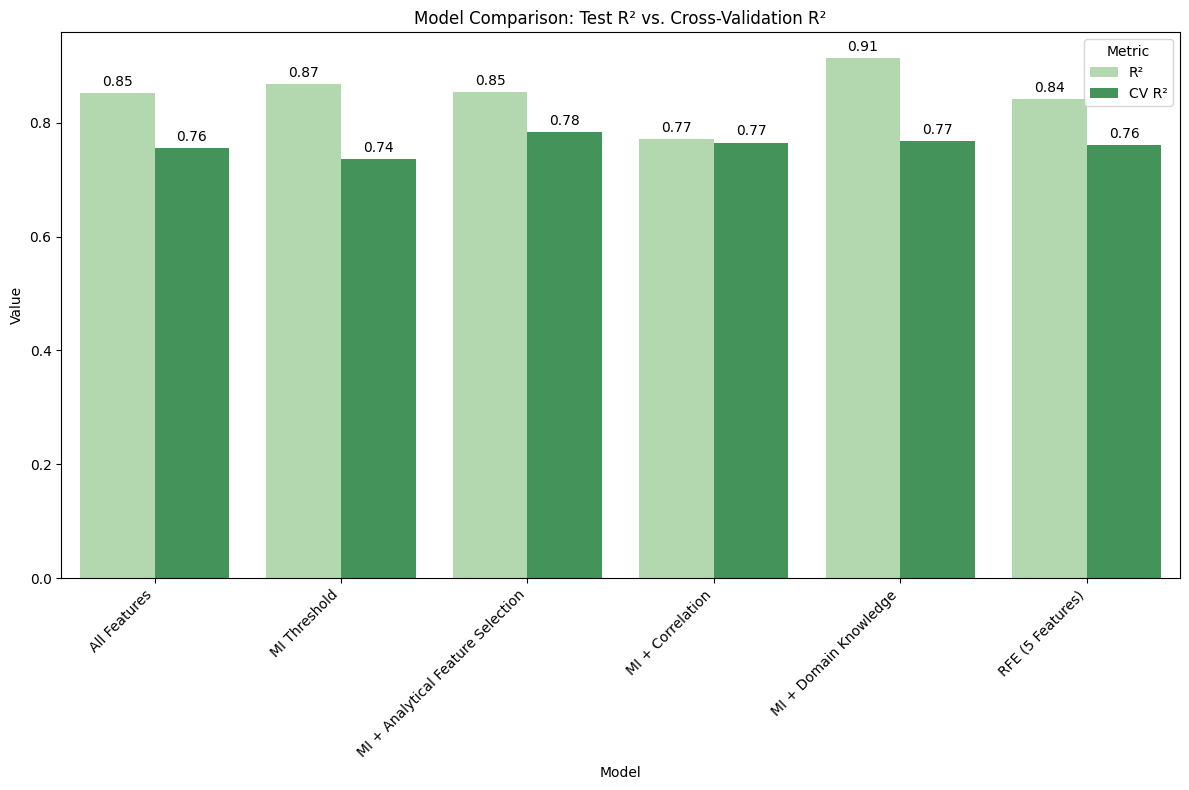

In [32]:
# Create a grouped bar chart to visualise the results
plot_data = results[["R²","CV R²"]].reset_index().melt(id_vars = "Model", var_name = "Metric", value_name = "Value")

plt.figure(figsize=(12, 8))
ax = sns.barplot(x = "Model", y = "Value", hue = "Metric", data = plot_data, palette = "Greens")
plt.title("Model Comparison: Test R² vs. Cross-Validation R²")
plt.xlabel("Model")
plt.ylabel("Value")
plt.xticks(rotation = 45, ha = "right")
plt.legend(title = "Metric", loc = "upper right" )

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)

plt.tight_layout()
plt.show()

The results show that the model based on domain knowledge achieved the highest test R² score, outperforming the other models by a noticeable margin. This indicates strong predictive performance when evaluated on the test dataset.

However, the model using analytical feature selection achieved the highest cross validated R² score (78.4%), suggesting it provides the best generalisation to unseen data.

In contrast, the correlation based model demonstrated lower test accuracy but relatively consistent performance between test and cross validation scores, indicating reduced overfitting, but with weaker predictive power.

The remaining models, including the baseline and RFE approaches, produced similar results with no significant improvement, showing that more complex feature selection methods do not necessarily lead to better performance.

Overall, these results highlight a clear trade-off between maximising accuracy and ensuring model generalisation. This demonstrates the importance of selecting a model based on the intended application, rather than relying solely on a single performance metric.

###🔍 Feature Importance

To better understand the differences in model performance, feature importance was analysed for the models with the highest test accuracy, highest cross validated score, and the smallest drop in performance when cross validated.

In [33]:
# Train model 3 - MI + analytical feature selection
model_3 = DecisionTreeRegressor(random_state=24)
model_3.fit(X_train_3, y_train)

# Train model 4 - MI + correlation
model_4 = DecisionTreeRegressor(random_state=24)
model_4.fit(X_train_4, y_train)

#Train model 5 - MI + domain knowledge
model_5 = DecisionTreeRegressor(random_state=24)
model_5.fit(X_train_5, y_train)

DecisionTreeRegressor(random_state=24)

In [34]:
# Extract feature importance scores from the models
feature_importance_3 = pd.Series(model_3.feature_importances_, index=X_train_3.columns).sort_values(ascending=False)
feature_importance_4 = pd.Series(model_4.feature_importances_, index=X_train_4.columns).sort_values(ascending=False)
feature_importance_5 = pd.Series(model_5.feature_importances_, index=X_train_5.columns).sort_values(ascending=False)

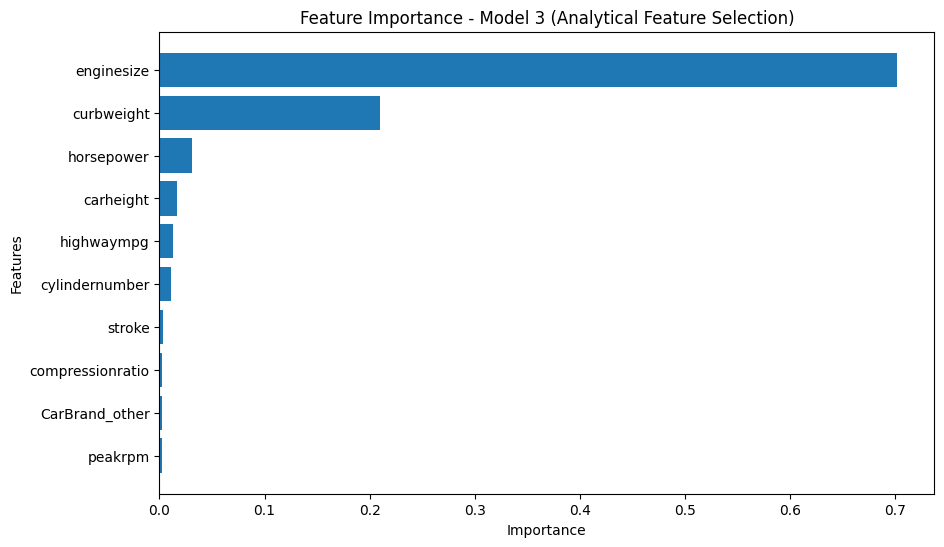

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_3.head(10).index, feature_importance_3.head(10).values)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Model 3 (Analytical Feature Selection)')
plt.show()

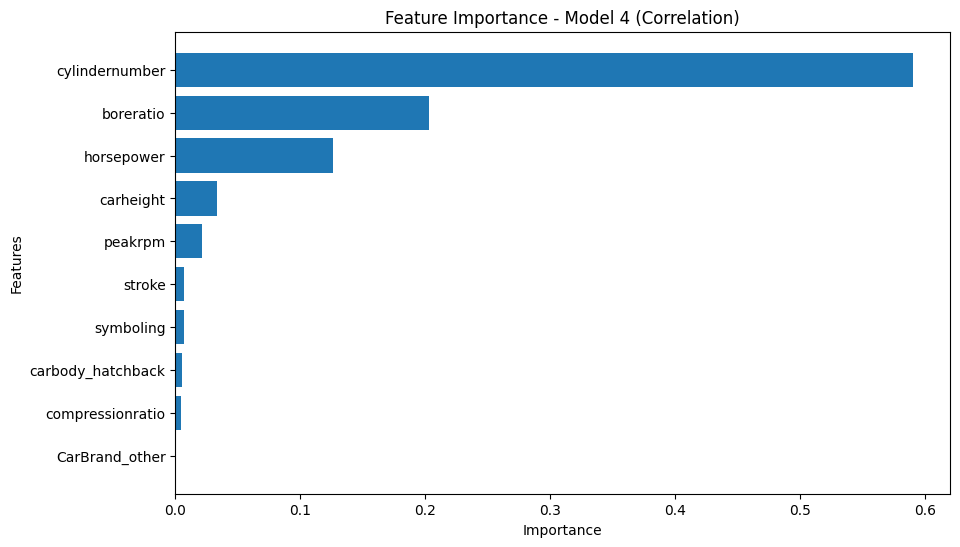

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_4.head(10).index, feature_importance_4.head(10).values)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Model 4 (Correlation)')
plt.show()

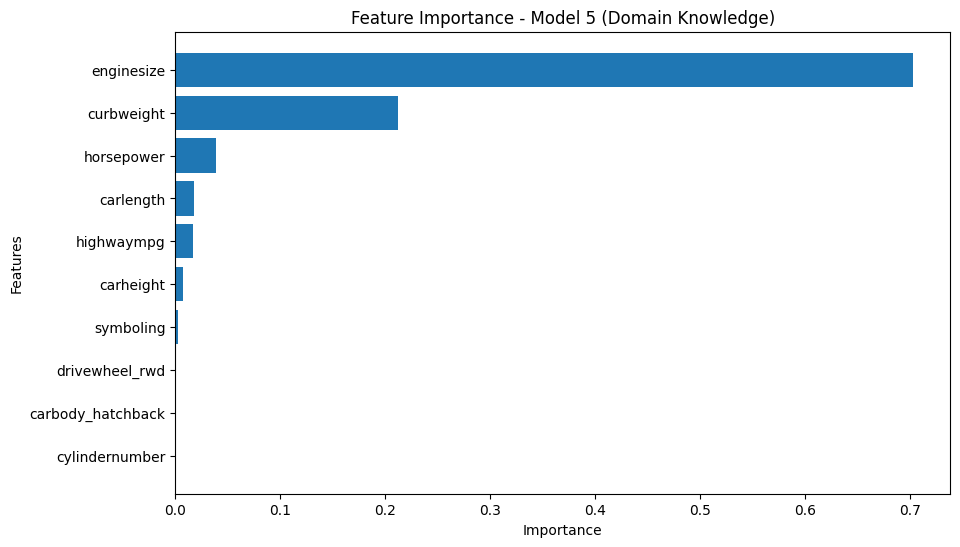

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_5.head(10).index, feature_importance_5.head(10).values)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Model 5 (Domain Knowledge)')
plt.show()

The analytical feature selection and domain knowledge models identified very similar features as most important, with the same top three features in both models. However, the domain knowledge model appears to rely more heavily on a smaller number of highly influential features. This suggests that the inclusion of additional lower importance features in the analytical feature selection model may contribute to its stronger generalisation performance.

In contrast, the correlation based model ranks different features as most important, likely because some of the key features used in the other models were removed during the feature selection process. The importance scores are also more evenly distributed across features, indicating that the model relies less on a small number of dominant predictors. This may explain its lower accuracy but improved stability when evaluated using cross validation.

These differences in feature importance across models highlight how feature selection strategies can significantly influence not only model performance, but also the interpretation of what drives predictions.

## 📝 **Conclusions**


Multiple feature selection strategies were evaluated to assess their impact on model performance and generalisation. The results showed that no single method consistently outperformed the others across all evaluation metrics.

While the domain knowledge approach achieved the highest test R² score, it demonstrated weaker generalisation when evaluated using cross validation. In contrast, the analytical feature selection approach achieved the strongest cross validated performance, although the improvement over other methods was relatively modest.

The choice of model ultimately depends on how the predictions will be applied. In more stable environments, where future data closely resembles the training dataset, a higher accuracy model such as the domain knowledge approach may be preferred. However, in more dynamic scenarios involving unseen or evolving data, a model with stronger generalisation performance, such as the analytical feature selection approach, is likely to provide more reliable predictions.

Further improvements could be achieved through additional feature engineering and model optimisation, which were beyond the scope of this project.

This project demonstrates the importance of combining statistical techniques with analytical judgement when developing robust predictive models.

##🚀 **Future Roadmap**

While this project has successfully concluded on the performance of several feature selection strategies for vehicle price prediction, there are additional opportunities to further progress development:

*   Automation of the data cleaning and processing phase through the creation of an ETL data pipeline, either using the existing libraries in python (e.g. SciKit-Learn) or a cloud platform such as AWS or GCP, in preparation for model industrialisation and deployment.
*   The replacement of the decision tree regressor with alternative methods such as ensemble models like RandomForest and XGBoost. While the decision tree offers high interpretability, its inherent high variance makes it more prone to overfitting compared to ensemble methods. The more advanced ensemble methods should improve the accuracy of the predictions while maintaining the robustness from the feature set selection.
*   Optimisation of the model through hyperparameter tuning. By employing strategies such as grid search cross validation, the optimal values of the hyperparameters will maximise the accuracy of the models whilst maintaining or improving the robustness of the predictions

